# ElasticNet Regression L1 vs. L2 Penalty Progression

ElasticNet regression combines L1 regularization (Lasso - which drives coefficients to exactly zero, producing sparsity) and L2 regularization (Ridge - which shrinks coefficients asymptotically to manage collinearity). The parameter `l1_ratio` controls the mixing weight between L1 (l1_ratio=1) and L2 (l1_ratio=0). This notebook generates a 20-feature dataset containing collinearity, fits ElasticNet across log regularizer alphas, and plots the coefficient shrinkage pathways in Matplotlib.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Generate synthetic dataset (300 samples, 20 features, 8 truly informative features)
np.random.seed(166)
n_samples = 300
n_features = 20

# Features matrix with built-in collinearity
X_base = np.random.normal(0, 1.0, (n_samples, 8))
# Create collinear features by adding noise
X_collinear = X_base[:, :6] + np.random.normal(0, 0.15, (n_samples, 6))
X_noise = np.random.normal(0, 1.0, (n_samples, 6))
X = np.hstack((X_base, X_collinear, X_noise))

# Linear target dependent on the 8 base features
true_coefs = np.array([4.5, -3.0, 2.5, 0.0, 1.8, -1.2, 0.0, 3.2] + [0.0]*12)
y = np.dot(X, true_coefs) + np.random.normal(0, 1.5, n_samples)

df_net = pd.DataFrame(X, columns=[f"Feat_{i+1:02d}" for i in range(n_features)])
df_net['Target'] = y
df_net.head(10)



,Feat_01,Feat_02,Feat_03,Feat_04,Feat_05,Feat_06,Feat_07,Feat_08,Feat_09,Feat_10,Feat_11,Feat_12,Feat_13,Feat_14,Feat_15,Feat_16,Feat_17,Feat_18,Feat_19,Feat_20,Target
0,0.870931,-0.538246,0.454274,1.350552,1.603189,0.790595,-1.707266,-0.109040,0.635083,-0.527593,0.360565,1.239405,1.681261,0.699333,-1.050316,-0.047450,-0.991732,0.494365,0.693390,-0.228227,7.628391
1,-0.113862,-0.940145,0.572553,-0.598175,1.055601,-0.516107,-0.734711,-0.870905,-0.224487,-1.110595,0.497058,-0.400144,0.891375,-0.294444,1.434065,-0.539505,-0.189161,0.601834,-0.857751,1.207614,5.219986
2,0.504813,0.708106,-1.593077,-0.434700,-0.936460,-0.072166,0.269637,-1.959714,0.431867,0.478186,-1.854529,-0.413156,-1.110006,0.000824,0.821118,0.956409,1.716232,0.296729,0.184402,0.137864,-13.114750
3,0.216576,-2.368780,-0.380087,-0.563807,1.222189,-0.162187,1.298576,0.916974,0.239599,-2.587075,-0.293051,-0.709439,1.301558,-0.317304,0.670049,1.552837,-0.119565,-0.686982,1.450396,-0.355803,12.775106
4,-1.478572,0.218995,-1.315987,-0.772442,1.000986,0.962275,-1.601249,0.626826,-1.464076,0.264165,-1.398211,-0.987950,0.723408,0.854622,-1.472255,1.496092,-0.603039,0.405177,-1.811928,-0.311455,-7.353383
5,-0.374366,-0.664029,0.549673,0.301045,0.897223,-1.174805,-0.662148,-1.997747,-0.467833,-0.385549,0.636331,0.409232,1.398496,-1.239784,-2.969199,1.721337,-2.744154,1.251406,-0.893633,0.467496,-0.906437
6,-0.239303,0.786123,0.166519,0.826335,1.346714,-0.928423,0.466000,-0.210683,-0.508901,0.806781,0.209798,0.921038,1.221300,-0.648864,0.491186,0.423983,-0.786374,0.045396,-1.050415,-0.347509,2.690011
7,-0.492053,0.925273,0.986933,-1.294192,-0.323817,0.743710,-1.436179,-2.200821,-0.547081,0.852012,0.960111,-1.351016,-0.237498,0.716113,0.606256,-0.040230,-0.001202,-0.550985,-0.798851,-0.738622,-12.583753
8,-1.037084,-0.234675,0.236502,1.445839,-0.251441,-0.361963,-0.430996,-0.191218,-0.796017,-0.417315,0.263397,1.461903,-0.433597,-0.383215,-1.166148,-0.256739,-0.602270,1.570648,-0.710275,0.902035,-4.662195
9,0.853624,-0.243518,1.360991,-0.563831,-1.306210,0.622766,-0.328960,-1.675174,0.935201,-0.397106,1.370647,-0.422079,-1.064801,0.554867,0.997787,0.357055,1.274186,0.199464,1.019239,1.795464,1.491750


## Model Performance Evaluation

We split variables and calculate test R² score under baseline ElasticNet configuration (alpha=0.1, l1_ratio=0.5).



In [2]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
active_coefs = np.sum(model.coef_ != 0.0)

print(f"ElasticNet Test R² Score:   {r2:.4f}")
print(f"Active Non-Zero Coefficients: {active_coefs}/{n_features} Features")



ElasticNet Test R² Score:   0.9577
Active Non-Zero Coefficients: 17/20 Features


## Regularization Pathway Shrinkage Curve

We fit ElasticNet across 100 alpha values ($10^{-3}$ to $10^1$) and plot the coefficient shrinkage pathways using Matplotlib.



<cell>:25: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



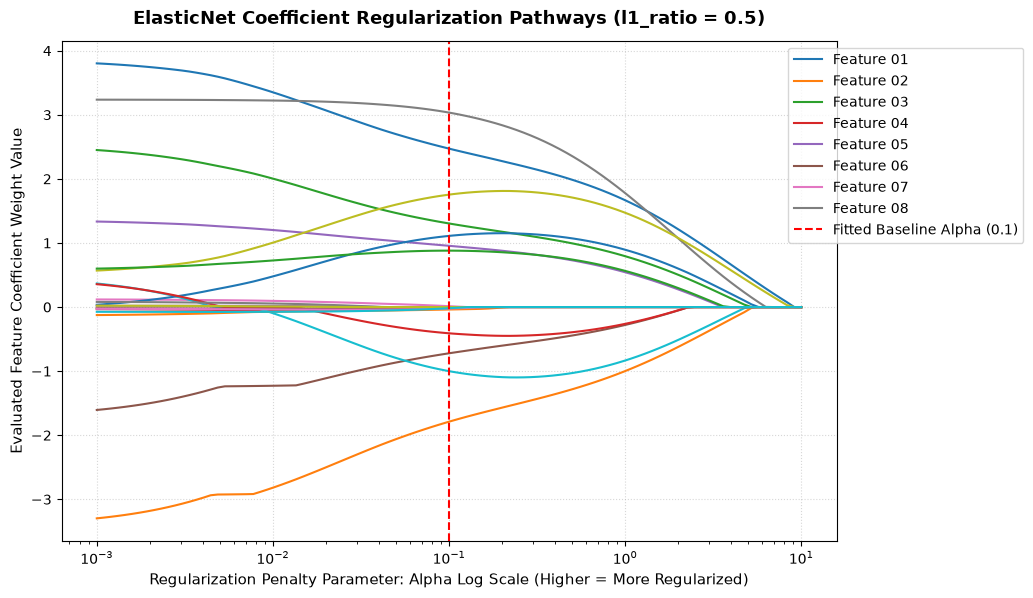

In [3]:
alphas = np.logspace(-3, 1, 100)
coef_paths = []

for a in alphas:
    clf = ElasticNet(alpha=a, l1_ratio=0.5, random_state=42)
    clf.fit(X_train, y_train)
    coef_paths.append(clf.coef_)

coef_paths = np.array(coef_paths) # Shape [100 alphas, 20 features]

plt.figure(figsize=(10, 6.5))

# Plot path lines
for i in range(n_features):
    plt.plot(alphas, coef_paths[:, i], label=f"Feature {i+1:02d}" if i < 8 else None)

plt.xscale('log')
plt.axvline(0.1, color='red', linestyle='--', linewidth=1.5, label='Fitted Baseline Alpha (0.1)')

plt.title('ElasticNet Coefficient Regularization Pathways (l1_ratio = 0.5)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Regularization Penalty Parameter: Alpha Log Scale (Higher = More Regularized)', fontsize=11)
plt.ylabel('Evaluated Feature Coefficient Weight Value', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1.0))
plt.show()
